# Q3. Feature Engineering and Regression Pipeline
Predicting `items_sold` using date engineering and scikit-learn pipelines.

## 1. Date Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
df = pd.read_csv(r"C:\Business analytics\ass 4 ml\data\q3_retail_promotions.csv")

# Date Engineering
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("Sample resulting dataframe:")
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end', 'items_sold']].head()

Sample resulting dataframe:


,transaction_date,year,month,day_of_week,is_month_end,items_sold
0,2022-01-01,2022,1,5,0,224
1,2022-01-01,2022,1,5,0,348
2,2022-01-02,2022,1,6,0,249
3,2022-01-02,2022,1,6,0,259
4,2022-01-03,2022,1,0,0,277


## 2. Temporal Train-Test Split
**Explanation:** A random split is inappropriate for time-series or time-ordered data because it leads to **temporal data leakage**. If we shuffle the data, the model might learn from future transactions to predict past ones. In a real-world setting, we only have historical data to predict the future, so we must maintain the temporal order and use the most recent records as the test set.

In [2]:
# Sort data by date
df = df.sort_values('transaction_date')

# Temporal split (80/20)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

target = 'items_sold'
cat_features = ['promotion_type', 'location_type', 'store_size']
num_features = ['year', 'month', 'day_of_week', 'is_month_end', 'is_weekend', 'is_festival', 'competition_density']

X_train, y_train = train_df[cat_features + num_features], train_df[target]
X_test, y_test = test_df[cat_features + num_features], test_df[target]

print(f"Training size: {len(X_train)}, Testing size: {len(X_test)}")

Training size: 960, Testing size: 240


## 3. Preprocessing Pipeline

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ]
)

## 4. Model Training and Evaluation

Linear Regression -> RMSE: 27.13, MAE: 21.07
Random Forest -> RMSE: 31.19, MAE: 25.03


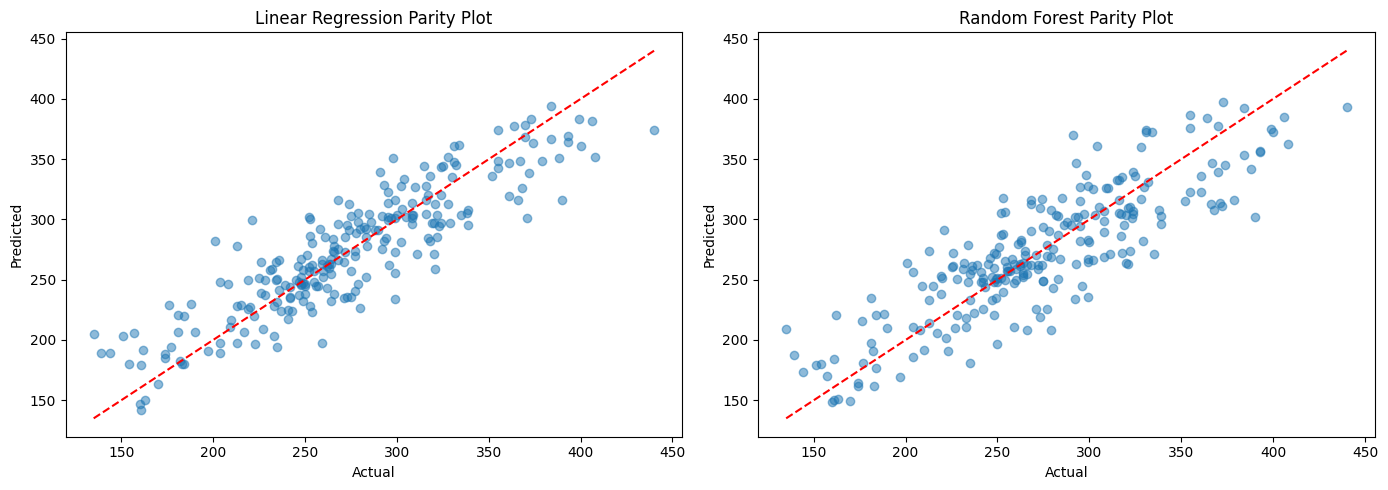


Top 5 Most Influential Features:
                feature  importance
16          is_festival    0.173610
10     store_size_small    0.165463
7   location_type_urban    0.107645
13          day_of_week    0.085597
15           is_weekend    0.069095


In [4]:
# Define pipelines
lr_pipe = Pipeline([('pre', preprocessor), ('reg', LinearRegression())])
rf_pipe = Pipeline([('pre', preprocessor), ('reg', RandomForestRegressor(random_state=42))])

# Fit
lr_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

# Predict
lr_preds = lr_pipe.predict(X_test)
rf_preds = rf_pipe.predict(X_test)

# Metrics
for name, preds in [("Linear Regression", lr_preds), ("Random Forest", rf_preds)]:
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    print(f"{name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# Parity Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, title in zip(axes, [lr_preds, rf_preds], ["Linear Regression", "Random Forest"]):
    ax.scatter(y_test, preds, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_title(f"{title} Parity Plot")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
plt.tight_layout()
plt.show()

# Feature Importance
ohe_names = rf_pipe.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(cat_features)
all_names = list(ohe_names) + num_features
importances = rf_pipe.named_steps['reg'].feature_importances_
fi_df = pd.DataFrame({'feature': all_names, 'importance': importances}).sort_values('importance', ascending=False)
print("\nTop 5 Most Influential Features:")
print(fi_df.head(5))